### Step 1: Data Acquisition & Preprocessing (ETL Pipeline)
To build a robust clustering model, we need comprehensive player statistics spanning multiple game situations. We utilize the `nhl-api-py` module to programmatically scrape data directly from the public NHL API for the last three seasons (2023-2024 to 2025-2026). 

Because the API divides statistics into different endpoint reports (e.g., Summary, Power Play, Real-Time tracking), we must loop through each report type, handle pagination to respect API limits, and merge the results into a single, unified dataset (`master_df`). We use the unique `playerId` as our primary key to ensure data aligns correctly across all reports, ignoring index here to keep each player season separate.

In [1]:
# Installs (Uncomment if running on a new environment)
#!pip install nhl-api-py
#!pip install pandas

# Imports
import pandas as pd
from nhlpy import NHLClient
from nhlpy.api.query.filters.season import SeasonQuery
from nhlpy.api.query.filters.game_type import GameTypeQuery
from nhlpy.api.query.builder import QueryBuilder
import time

# Initialize the NHL API client
client = NHLClient()

# Define the scope of our analysis (Last 3 seasons)
seasons = ["20232024", "20242025", "20252026"]

# The specific stat endpoints we need to pull to get a full picture of a player's playstyle
reports_to_fetch = ['summary', 'realtime', 'powerplay', 'penaltykill', 'goalsForAgainst', 'percentages']

all_data = []
query_builder = QueryBuilder()

print("Building Master Dataset for Clustering...")

for season in seasons:
    print(f"\nFetching data for {season}...")
    season_df = None
    
    # 1. Build Query Context (Filter for Regular Season games only: game_type="2")
    filters = [
        GameTypeQuery(game_type="2"),
        SeasonQuery(season_start=season, season_end=season) 
    ]
    query_context = query_builder.build(filters=filters)
    
    for report in reports_to_fetch:
        print(f"  -> Scraping {report} report...", end=" ")
        
        report_data = []
        start = 0
        limit = 100  # Fetch 100 players at a time to respect API rate limits
        
        # 2. The Pagination Loop
        try:
            while True:
                # Ping the API for the current batch of players
                response = client.stats.skater_stats_with_query_context(
                    report_type=report,
                    query_context=query_context,
                    aggregate=False,  # False ensures we get distinct individual player rows
                    start=start,
                    limit=limit
                )
                
                # Extract the batch data and the total available records limit
                total = response.get('total', 0) 
                batch_data = response.get('data', [])
                
                report_data.extend(batch_data)
                
                # Break the loop if we've collected everything or the API returns an empty batch
                if len(report_data) >= total or len(batch_data) == 0:
                    break
                    
                start += limit
                time.sleep(0.1)  # Small pause between pages to avoid timeout errors
                
            # Convert the fully scraped list for this specific report into a DataFrame
            df = pd.DataFrame(report_data)
            
            if df.empty:
                print("Warning: No data returned.")
                continue

            # 3. Align and Merge Data
            # We set the index to playerId so that when we pull the next report (e.g., 'powerplay'),
            # it merges smoothly with the 'summary' data for the exact same player.
            df = df.set_index('playerId')
            
            if season_df is None:
                season_df = df
            else:
                # combine_first fills in missing data without overwriting existing columns
                season_df = season_df.combine_first(df)
                
            print(f"Done! ({len(report_data)} players)")
            time.sleep(0.5)  # Pause before hitting the next report endpoint
            
        except Exception as e:
            print(f"FAILED: {e}")
            
    # 4. Finalize the season's data and append to our master list
    if season_df is not None and not season_df.empty:
        season_df = season_df.reset_index()
        season_df['seasonId'] = season
        all_data.append(season_df)

# 5. Combine all seasons and Clean
print("\nCombining and cleaning data...")
master_df = pd.concat(all_data, ignore_index=True) # Note: ignore_index=True to allow us to use multiple different seasons without index conflicts

# Fill remaining NaNs with 0 (e.g., if a player had 0 powerplay time, the API leaves it blank)
master_df = master_df.fillna(0)

print("\nDataset Complete! Ready for feature engineering.")
print(f"Total Rows (Player-Seasons): {len(master_df)}")
print(f"Total Columns (Features): {len(master_df.columns)}")

Building Master Dataset for Clustering...

Fetching data for 20232024...
  -> Scraping summary report... Done! (924 players)
  -> Scraping realtime report... Done! (924 players)
  -> Scraping powerplay report... Done! (924 players)
  -> Scraping penaltykill report... Done! (924 players)
  -> Scraping goalsForAgainst report... Done! (924 players)
  -> Scraping percentages report... Done! (924 players)

Fetching data for 20242025...
  -> Scraping summary report... Done! (920 players)
  -> Scraping realtime report... Done! (920 players)
  -> Scraping powerplay report... Done! (920 players)
  -> Scraping penaltykill report... Done! (920 players)
  -> Scraping goalsForAgainst report... Done! (920 players)
  -> Scraping percentages report... Done! (920 players)

Fetching data for 20252026...
  -> Scraping summary report... Done! (940 players)
  -> Scraping realtime report... Done! (940 players)
  -> Scraping powerplay report... Done! (940 players)
  -> Scraping penaltykill report... FAILED: 

### Step 2: Integrating Advanced Puck and Player Tracking (NHL EDGE Data)
To capture the nuances of a player's physical and spatial profile (such as maximum skating speed and shot location), we augment our traditional box-score statistics with advanced NHL EDGE tracking data. 

Because the NHL EDGE API requires querying each player-season combination individually (resulting in over 2,700 separate API requests), we utilize Python's `concurrent.futures.ThreadPoolExecutor` to parallelize the network calls, significantly reducing our data acquisition time. Finally, we parse the returned nested JSON arrays to extract granular spatial metrics, giving us precise data on high-danger shot volumes and crease activity.

In [2]:
import pandas as pd
import time
import concurrent.futures
import ast

def safe_parse(val):
    """
    Safely evaluates stringified representations of lists/dictionaries returned by the API 
    back into native Python objects. Returns an empty list if the value is null or malformed.
    """
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    return []

# 1. Prepare a list of tasks (tuples of playerId and seasonId) for the thread pool
fetch_tasks = [(row['playerId'], row['seasonId']) for index, row in master_df.iterrows()]

edge_master_df_list = []
failed_fetches = []

def fetch_edge_data(task):
    """
    Worker function to fetch advanced EDGE tracking data for a specific player-season.
    Includes slight sleep delays to respect API rate limits and prevent timeouts.
    """
    p_id, p_season = task
    try:
        edge_stats = client.edge.skater_detail(player_id=p_id, season=p_season)
        
        # Remove redundant nested player bio blocks to save memory
        edge_stats.pop('player', None)
        edge_stats.pop('seasonsWithEdgeStats', None)
        
        # Attach primary keys so we can successfully left-join this back to master_df
        edge_stats['playerId'] = p_id
        edge_stats['seasonId'] = p_season
        
        time.sleep(0.05) 
        
        return edge_stats
    except Exception as e:
        return {'error': True, 'playerId': p_id, 'seasonId': p_season, 'msg': str(e)}

print(f"Starting multithreaded fetch for {len(fetch_tasks)} player-seasons...")
start_time = time.time()

# 2. Execute the Thread Pool
# We use max_workers=10 to ping the API concurrently, dramatically speeding up the ETL process
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    results = executor.map(fetch_edge_data, fetch_tasks)
    
    for count, result in enumerate(results, 1):
        if 'error' in result:
            failed_fetches.append(result)
        else:
            edge_master_df_list.append(result)
            
        if count % 500 == 0:
            print(f"Processed {count}/{len(fetch_tasks)} records...")

end_time = time.time()
print(f"Fetch complete in {round(end_time - start_time, 2)} seconds!")
print(f"Success: {len(edge_master_df_list)} | Failed: {len(failed_fetches)}")

if failed_fetches:
    print("First 3 failures:", failed_fetches[:3])

# 3. Flatten and Merge EDGE data
print("Flattening and merging EDGE data...")

# pd.json_normalize flattens deeply nested JSON objects into standard dataframe columns
edge_master_df = pd.json_normalize(edge_master_df_list)

# Left join ensures we retain all players, even if the EDGE API was missing tracking data for them
final_df = pd.merge(master_df, edge_master_df, on=['playerId', 'seasonId'], how='left')

# Drop irrelevant visual overlay data returned by the API to keep our dimensions clean
cols_to_drop = [c for c in final_df.columns if 'overlay' in str(c)]
final_df = final_df.drop(columns=cols_to_drop)

# 4. Extract Nested Shot Location Metrics
print("Extracting nested shot location metrics...")

# Ensure columns exist before applying the safe parser
if 'sogSummary' in final_df.columns and 'sogDetails' in final_df.columns:
    final_df['sogSummary'] = final_df['sogSummary'].apply(safe_parse)
    final_df['sogDetails'] = final_df['sogDetails'].apply(safe_parse)

    # Extract Danger Zones using generator expressions to find specific dictionaries in the nested lists
    final_df['highDangerShots'] = final_df['sogSummary'].apply(
        lambda x: next((item.get('shots', 0) for item in x if item.get('locationCode') == 'high'), 0)
    )
    final_df['highDangerGoals'] = final_df['sogSummary'].apply(
        lambda x: next((item.get('goals', 0) for item in x if item.get('locationCode') == 'high'), 0)
    )
    final_df['midDangerShots'] = final_df['sogSummary'].apply(
        lambda x: next((item.get('shots', 0) for item in x if item.get('locationCode') == 'mid'), 0)
    )
    final_df['longDangerShots'] = final_df['sogSummary'].apply(
        lambda x: next((item.get('shots', 0) for item in x if item.get('locationCode') == 'long'), 0)
    )

    # Extract Specific Ice Areas (Crease vs Slot)
    final_df['shotsCrease'] = final_df['sogDetails'].apply(
        lambda x: next((item.get('shots', 0) for item in x if item.get('area') == 'Crease'), 0)
    )
    final_df['shotsLowSlot'] = final_df['sogDetails'].apply(
        lambda x: next((item.get('shots', 0) for item in x if item.get('area') == 'Low Slot'), 0)
    )
    final_df['shotsHighSlot'] = final_df['sogDetails'].apply(
        lambda x: next((item.get('shots', 0) for item in x if item.get('area') == 'High Slot'), 0)
    )

    # Drop the raw, unflattened dictionary lists to prevent K-Means processing errors
    final_df = final_df.drop(columns=['sogSummary', 'sogDetails'])

print("Pipeline Complete!")

# Output the results
columns_to_preview = ['playerId', 'seasonId', 'highDangerShots', 'shotsCrease', 'shotsLowSlot']

# Find available columns that match our preview list to avoid KeyError
preview_cols = [col for col in columns_to_preview if col in final_df.columns]
display(final_df[preview_cols].head())

print("\nFinal DataFrame Info:")
final_df.info(verbose=True, show_counts=True)

Starting multithreaded fetch for 2784 player-seasons...
Processed 500/2784 records...
Processed 1000/2784 records...
Processed 1500/2784 records...
Processed 2000/2784 records...
Processed 2500/2784 records...
Fetch complete in 139.83 seconds!
Success: 2782 | Failed: 2
First 3 failures: [{'error': True, 'playerId': 8478400, 'seasonId': '20242025', 'msg': 'Request to edge/skater-detail/8478400/20242025/2 failed'}, {'error': True, 'playerId': 8481848, 'seasonId': '20242025', 'msg': 'Request to edge/skater-detail/8481848/20242025/2 failed'}]
Flattening and merging EDGE data...
Extracting nested shot location metrics...
Pipeline Complete!


,playerId,seasonId,highDangerShots,shotsCrease,shotsLowSlot
0,8470600,20232024,1,0,1
1,8470604,20232024,37,4,33
2,8470610,20232024,24,5,19
3,8470613,20232024,3,0,3
4,8470621,20232024,42,5,37



Final DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2784 entries, 0 to 2783
Data columns (total 149 columns):
 #    Column                                     Non-Null Count  Dtype  
---   ------                                     --------------  -----  
 0    playerId                                   2784 non-null   int64  
 1    assists                                    2784 non-null   int64  
 2    blockedShots                               2784 non-null   int64  
 3    blockedShotsPer60                          2784 non-null   float64
 4    emptyNetAssists                            2784 non-null   float64
 5    emptyNetGoals                              2784 non-null   int64  
 6    emptyNetPoints                             2784 non-null   float64
 7    evGoals                                    2784 non-null   int64  
 8    evPoints                                   2784 non-null   int64  
 9    evenStrengthGoalDifference                 2784 non-null   f

### Step 3: Data Cleaning and Feature Engineering
Raw counting stats (e.g., total hits or goals) are heavily biased by a player's deployment volume. If fed into a distance-based clustering algorithm like K-Means, the model will simply group players by total ice time rather than true playstyle efficiency.

To solve this, we engineer rate statistics. We calculate the total seasonal ice time a player spent in specific game states (Even Strength, Power Play, Penalty Kill) and convert their raw stats into "Per 60 Minutes" rates. We also filter out players with fewer than 10 games played to prevent extreme outliers caused by tiny sample sizes (e.g., AHL call-ups).

In [12]:
import numpy as np
import pandas as pd

"""
Data Preprocessing Pipeline:
1. Removes missing data to maintain mathematical integrity.
2. Filters out low-sample-size players to prevent skewed rate stats.
3. Engineers new features by converting raw volume stats into standardized Per-60 rates.
"""

# 1. Clean data by removing nulls
print(f"Starting rows: {len(final_df)}")
cleaned_df = final_df.dropna()
print(f"Rows after blanket dropna: {len(cleaned_df)}")

# 2. Filter out small sample sizes (Must have played at least 10 games)
cleaned_df = cleaned_df[cleaned_df['gamesPlayed'] >= 10].copy()
print(f"Rows after 10-game filter: {len(cleaned_df)}")

print("\nConverting raw volume stats to standardized rate stats...")

# Feature Engineering: Creating Rate Denominators

# Note: timeOnIce in the NHL API is typically returned in seconds.
# We divide by 3600 to convert total seconds into 60-minute blocks (full games).
# We use replace(0, np.nan) to prevent Division by Zero errors for players who never play special teams.

total_60_blocks = ((cleaned_df['timeOnIcePerGame'] * cleaned_df['gamesPlayed']) / 3600).replace(0, np.nan)
ev_60_blocks = ((cleaned_df['evenStrengthTimeOnIcePerGame'] * cleaned_df['gamesPlayed']) / 3600).replace(0, np.nan)

# Unified to Per 60 for clean downstream clustering and analysis
pp_60_blocks = ((cleaned_df['powerPlayTimeOnIcePerGame'] * cleaned_df['gamesPlayed']) / 3600).replace(0, np.nan)
sh_60_blocks = ((cleaned_df['shortHandedTimeOnIcePerGame'] * cleaned_df['gamesPlayed']) / 3600).replace(0, np.nan)

# Group raw counting stats into lists based on game state
overall_stats = [
    'goals', 'assists', 'points', 'shots', 'blockedShots', 
    'hits', 'takeaways', 'giveaways', 'missedShots', 'totalShotAttempts',
    'penaltyMinutes', 'highDangerShots', 'longDangerShots'
]

even_strength_stats = ['evGoals', 'evPoints'] 

power_play_stats = [
    'ppGoals', 'ppAssists', 'ppPoints', 'ppShots', 
    'ppPrimaryAssists', 'ppSecondaryAssists', 'ppIndividualSatFor'
]

short_handed_stats = [
    'shGoals', 'shAssists', 'shPoints', 'shShots', 
    'shPrimaryAssists', 'shSecondaryAssists', 'shIndividualSatFor'
]

# Automate the conversion math

# Overall -> Per 60
for stat in overall_stats:
    if stat in cleaned_df.columns:
        cleaned_df[f'{stat}Per60'] = cleaned_df[stat] / total_60_blocks

# Even Strength -> Per 60
for stat in even_strength_stats:
    if stat in cleaned_df.columns:
        cleaned_df[f'{stat}Per60'] = cleaned_df[stat] / ev_60_blocks

# Power Play -> Per 60
for stat in power_play_stats:
    if stat in cleaned_df.columns:
        cleaned_df[f'{stat}Per60'] = cleaned_df[stat] / pp_60_blocks

# Penalty Kill (Short Handed) -> Per 60
for stat in short_handed_stats:
    if stat in cleaned_df.columns:
        cleaned_df[f'{stat}Per60'] = cleaned_df[stat] / sh_60_blocks

# Clean up the NaNs generated by players who had 0 ice time in a specific category
cleaned_df = cleaned_df.fillna(0)

# Check the results
print("Feature engineering complete!")
columns_to_preview = ['playerId', 'lastName', 'gamesPlayed', 'hitsPer60', 'blockedShotsPer60', 'ppGoalsPer60', 'shShotsPer60']

# Ensure columns exist before previewing
preview_cols = [col for col in columns_to_preview if col in cleaned_df.columns]
display(cleaned_df[preview_cols].head(10))

Starting rows: 2784
Rows after blanket dropna: 2762
Rows after 10-game filter: 2311

Converting raw volume stats to standardized rate stats...
Feature engineering complete!


,playerId,lastName,gamesPlayed,hitsPer60,blockedShotsPer60,ppGoalsPer60,shShotsPer60
0,8470600,Suter,82,3.322459,4.288290,0.000000,1.132090
1,8470604,Carter,72,5.502256,2.187644,1.992270,2.878162
2,8470610,Parise,30,3.084701,3.855876,0.000000,0.000000
3,8470613,Burns,82,1.395296,2.960750,1.113350,1.907130
4,8470621,Perry,54,3.570275,1.411504,1.787198,0.000000
5,8470794,Pavelski,82,3.264734,3.047085,3.021749,0.000000
6,8470966,Giordano,46,4.003227,6.750540,0.000000,3.461007
7,8471214,Ovechkin,79,6.401194,1.066866,2.168878,0.000000
8,8471215,Malkin,82,1.141782,1.653616,1.284191,0.000000
9,8471218,Wheeler,54,2.708409,2.708409,1.142511,0.000000


### Step 4: Data Persistence and Checkpointing
Because the data acquisition and preprocessing pipeline involves over 2,000 API calls and takes significant time to execute, we serialize the fully cleaned and engineered dataframe to a local CSV file. This establishes a persistent data checkpoint. During the exploratory data analysis (EDA) and machine learning phases, we can load this static file instantly, ensuring our clustering algorithms run efficiently without needing to continually query the NHL servers.

In [13]:
"""
Data Persistence:
Saves the fully processed and rate-adjusted dataframe to a local CSV file.
Setting index=False ensures we don't write the arbitrary Pandas row numbers 
into our final dataset, keeping the schema clean for K-Means.
"""

# Define the output file name
output_filename = 'final_player_stats.csv'

# Export the dataframe to a CSV file in the current working directory
cleaned_df.to_csv(output_filename, index=False)

# Print a confirmation and the final dimensions to verify the export
print(f"✅ Success! Checkpoint saved locally as '{output_filename}'.")
print(f"Final Dataset Dimensions: {cleaned_df.shape[0]} rows by {cleaned_df.shape[1]} columns.")
print("The ETL pipeline is complete. You may now proceed to Exploratory Data Analysis.")

✅ Success! Checkpoint saved locally as 'final_player_stats.csv'.
Final Dataset Dimensions: 2311 rows by 162 columns.
The ETL pipeline is complete. You may now proceed to Exploratory Data Analysis.


### Step 5: Exploratory Data Analysis (Variable Correlation)
Before feeding our engineered features into a clustering algorithm, we must check for multicollinearity. K-Means clustering relies on Euclidean distance; if two variables are highly correlated (e.g., `goalsPer60` and `shotsPer60`), they effectively measure the same underlying trait. Leaving them as raw inputs would cause the algorithm to double-count that trait, warping the resulting clusters.

To visualize this, we separate the dataset by position (since Forwards and Defensemen have fundamentally different statistical distributions) and generate correlation heatmaps for our core playstyle features.

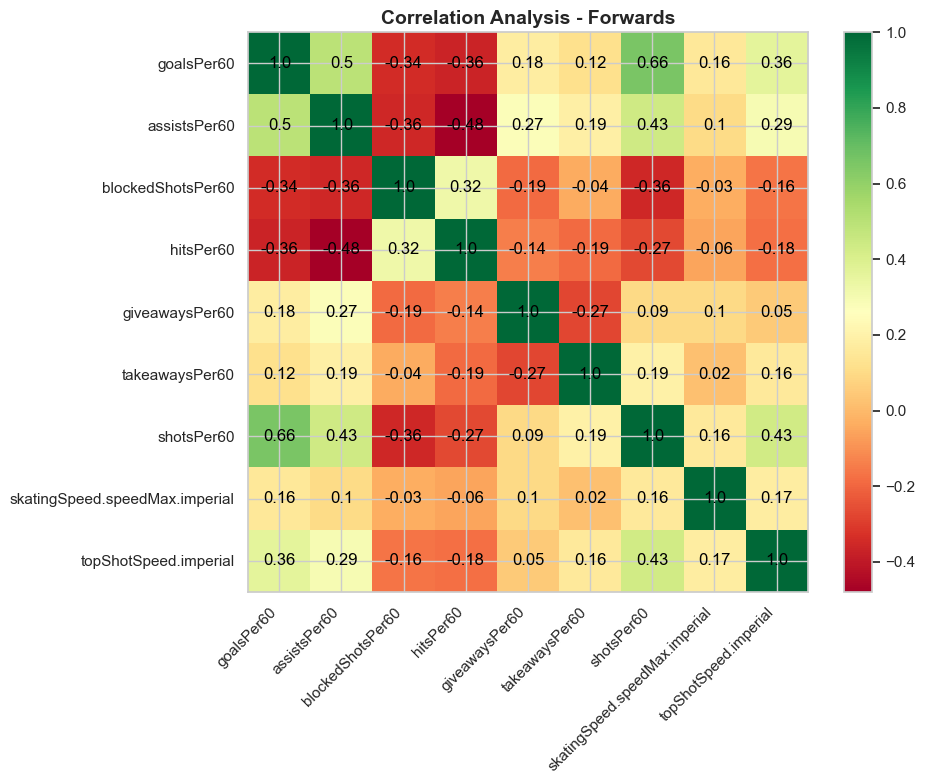

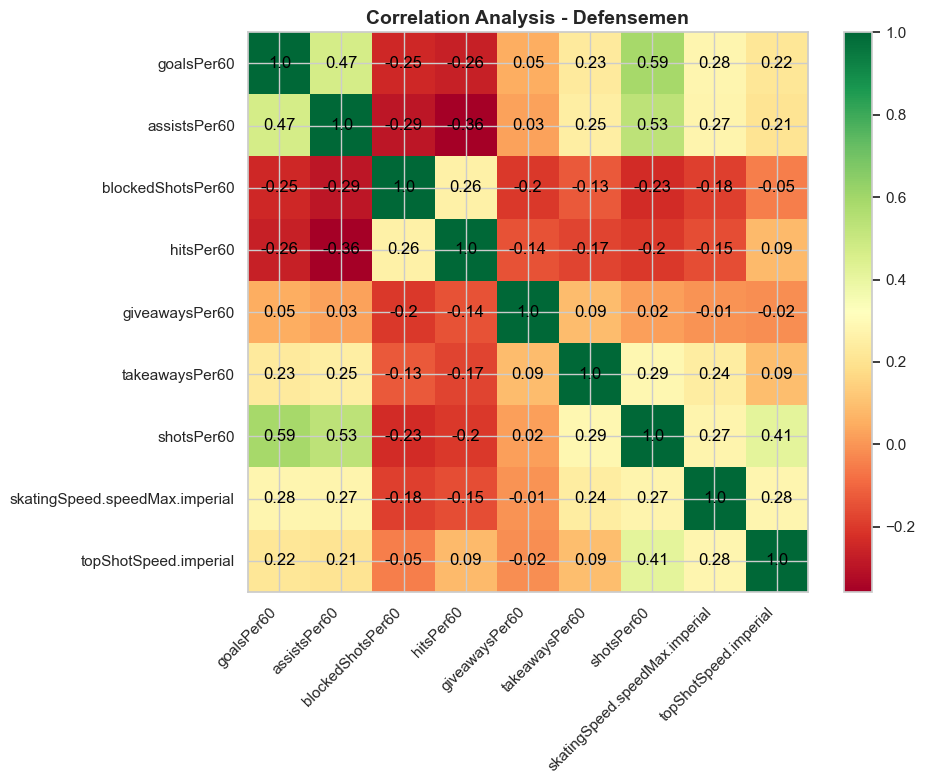

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

"""
Exploratory Data Analysis - Correlation Matrices:
Loads the static checkpoint dataset, separates skaters by position, and 
calculates the Pearson correlation coefficient between our selected features.
The resulting heatmaps visually identify highly correlated variables that 
will need to be compressed via Dimensionality Reduction (PCA) in the next step.
"""

# 1. Load the persistent data checkpoint
df = pd.read_csv('final_player_stats.csv')

# Separate by position (Forwards and Defensemen require separate models)
forwards = df[df['positionCode'].isin(['C', 'L', 'R'])]
defense = df[df['positionCode'] == 'D']

# 2. Define the core "Playstyle" features to analyze
features = [
    'goalsPer60', 'assistsPer60', 'blockedShotsPer60', 'hitsPer60', 
    'giveawaysPer60', 'takeawaysPer60', 'shotsPer60', 
    'skatingSpeed.speedMax.imperial', 'topShotSpeed.imperial'
]

# PLOT 1: Forwards Correlation Heatmap
# Calculate the Pearson correlation matrix
corr_f = forwards[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_f, cmap='RdYlGn') # Red = Negative Correlation, Green = Positive

# Loop over data dimensions and create text annotations
for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, round(corr_f.iloc[i, j], 2), ha="center", va="center", color="black")

# Formatting
ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)
plt.title("Correlation Analysis - Forwards", fontsize=14, fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.show()

# PLOT 2: Defensemen Correlation Heatmap 
corr_d = defense[features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_d, cmap='RdYlGn')

for i in range(len(features)):
    for j in range(len(features)):
        ax.text(j, i, round(corr_d.iloc[i, j], 2), ha="center", va="center", color="black")

ax.set_xticks(range(len(features)))
ax.set_yticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticklabels(features)
plt.title("Correlation Analysis - Defensemen", fontsize=14, fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Step 6: Dimensionality Reduction via Principal Component Analysis (PCA)
As identified in our exploratory data analysis, several core hockey statistics exhibit high multicollinearity (e.g., goals strongly correlate with shots). If these raw variables are fed directly into a distance-based clustering algorithm like K-Means, the algorithm will implicitly overweight offensive traits, warping the resulting clusters.

To resolve this, we employ **Principal Component Analysis (PCA)**. PCA transforms our highly correlated feature set into a smaller number of mathematically independent, orthogonal dimensions ("Principal Components"). 
1. We isolate our target playstyle metrics and apply a `StandardScaler` so that high-variance percentage stats do not overpower lower-variance rate stats.
2. We run PCA and generate a Scree Plot (Explained Variance) to identify the optimal number of components required to retain >80% of the original data's variance.
3. We extract the "feature loadings" (weights) of each component to understand what these new mathematical dimensions represent in actual hockey terms.

Forwards ready for PCA (Cleaned): 997
Defensemen ready for PCA (Cleaned): 532

Executing PCA Pipeline for: Forwards


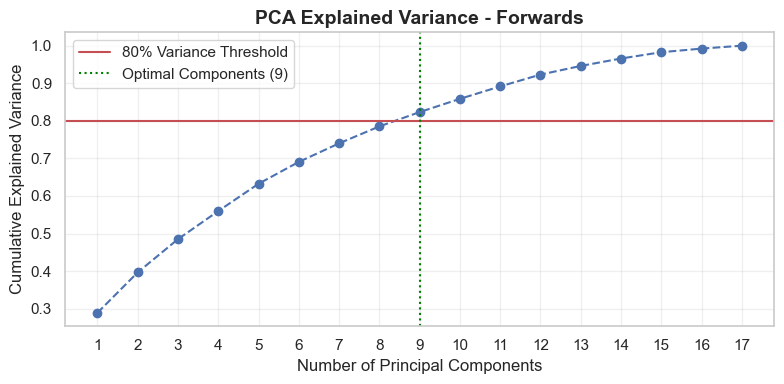

Result: 9 components are required to explain >= 80% of the variance.

--- Interpreting the 9 Mathematical Dimensions ---

PC1 is heavily driven by:
  (+) High: ppTimeOnIcePctPerGame (0.39), goalsPer60 (0.37)
  (-) Low:  hitsPer60 (-0.26), blockedShotsPer60 (-0.25)

PC2 is heavily driven by:
  (+) High: shTimeOnIcePctPerGame (0.50), faceoffWinPct (0.27)
  (-) Low:  penaltyMinutesPer60 (-0.43), hitsPer60 (-0.39)

PC3 is heavily driven by:
  (+) High: takeawaysPer60 (0.48), topShotSpeed.imperial (0.33)
  (-) Low:  giveawaysPer60 (-0.47), zoneStartPct5v5 (-0.18)

PC4 is heavily driven by:
  (+) High: highDangerShotsPer60 (0.56), shootingPct5v5 (0.35)
  (-) Low:  longDangerShotsPer60 (-0.46), topShotSpeed.imperial (-0.31)

PC5 is heavily driven by:
  (+) High: skatingSpeed.burstsOver20.value (0.44), giveawaysPer60 (0.43)
  (-) Low:  takeawaysPer60 (-0.37), zoneStartPct5v5 (-0.17)

PC6 is heavily driven by:
  (+) High: faceoffWinPct (0.75), giveawaysPer60 (0.24)
  (-) Low:  shootingPct5v5 (-

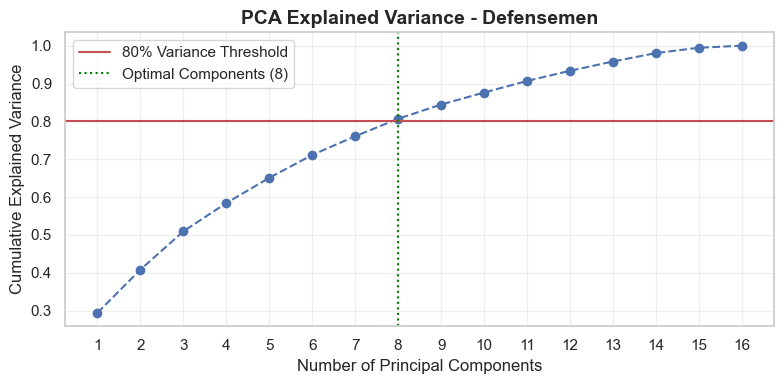

Result: 8 components are required to explain >= 80% of the variance.

--- Interpreting the 8 Mathematical Dimensions ---

PC1 is heavily driven by:
  (+) High: shotsPer60 (0.39), ppTimeOnIcePctPerGame (0.38)
  (-) Low:  hitsPer60 (-0.23), blockedShotsPer60 (-0.22)

PC2 is heavily driven by:
  (+) High: topShotSpeed.imperial (0.51), hitsPer60 (0.40)
  (-) Low:  zoneStartPct5v5 (-0.28), giveawaysPer60 (-0.16)

PC3 is heavily driven by:
  (+) High: shTimeOnIcePctPerGame (0.54), skatingSpeed.burstsOver20.value (0.29)
  (-) Low:  penaltyMinutesPer60 (-0.44), zoneStartPct5v5 (-0.30)

PC4 is heavily driven by:
  (+) High: shootingPct5v5 (0.61), giveawaysPer60 (0.58)
  (-) Low:  highDangerShotsPer60 (-0.30), blockedShotsPer60 (-0.22)

PC5 is heavily driven by:
  (+) High: shootingPct5v5 (0.53), highDangerShotsPer60 (0.35)
  (-) Low:  giveawaysPer60 (-0.45), longDangerShotsPer60 (-0.29)

PC6 is heavily driven by:
  (+) High: takeawaysPer60 (0.51), highDangerShotsPer60 (0.49)
  (-) Low:  assists

In [29]:
"""
Dimensionality Reduction Pipeline:
Standardizes advanced hockey metrics and applies PCA. 
Includes specific cleaning steps to remove 'disguised' missing data 
and splits feature inputs by position to prevent artifacts (like defensemen taking faceoffs).
Finally, prints the Feature Loadings so human analysts can interpret the new mathematical dimensions.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 1. Separate Feature Lists by Position
fwd_features = [
    'goalsPer60', 'assistsPer60', 'shotsPer60', 
    'hitsPer60', 'blockedShotsPer60', 
    'takeawaysPer60', 'giveawaysPer60',
    'skatingSpeed.burstsOver20.value',  
    'topShotSpeed.imperial', 'zoneStartPct5v5',
    'highDangerShotsPer60', 'longDangerShotsPer60', 
    'shootingPct5v5', 'penaltyMinutesPer60', 
    'ppTimeOnIcePctPerGame', 'shTimeOnIcePctPerGame',
    'faceoffWinPct' # <--- Forwards only
]

def_features = [
    'goalsPer60', 'assistsPer60', 'shotsPer60', 
    'hitsPer60', 'blockedShotsPer60', 
    'takeawaysPer60', 'giveawaysPer60',
    'skatingSpeed.burstsOver20.value',  
    'topShotSpeed.imperial', 'zoneStartPct5v5',
    'highDangerShotsPer60', 'longDangerShotsPer60', 
    'shootingPct5v5', 'penaltyMinutesPer60',
    'ppTimeOnIcePctPerGame', 'shTimeOnIcePctPerGame'
]

# 2. Fix the "Disguised Missing Data" Bug
tracking_stats_to_check = ['zoneStartPct5v5', 'topShotSpeed.imperial', 'skatingSpeed.burstsOver20.value']
for col in tracking_stats_to_check:
    if col in cleaned_df.columns:
        cleaned_df[col] = cleaned_df[col].replace(0.0, np.nan)

# 3. Split data and drop the TRULY missing rows
forwards_df = cleaned_df[cleaned_df['positionCode'].isin(['C', 'L', 'R'])].dropna(subset=fwd_features).copy()
defense_df = cleaned_df[cleaned_df['positionCode'] == 'D'].dropna(subset=def_features).copy()

print(f"Forwards ready for PCA (Cleaned): {len(forwards_df)}")
print(f"Defensemen ready for PCA (Cleaned): {len(defense_df)}\n")

# 4. Define the Unified PCA Function
def run_and_interpret_pca(df, features, role_name):
    print(f"{'='*50}")
    print(f"Executing PCA Pipeline for: {role_name}")
    print(f"{'='*50}")
    
    # Standardize the features
    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Run full PCA to evaluate variance retention
    full_pca = PCA()
    full_pca.fit(X_scaled)
    
    # Find the "Elbow" for 80% variance
    cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)
    n_components = np.argmax(cumulative_variance >= 0.80) + 1
    
    # Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(features) + 1), cumulative_variance, marker='o', linestyle='--')
    plt.axhline(y=0.80, color='r', linestyle='-', label='80% Variance Threshold')
    plt.axvline(x=n_components, color='green', linestyle=':', label=f'Optimal Components ({n_components})')
    plt.title(f'PCA Explained Variance - {role_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.xticks(range(1, len(features) + 1))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Result: {n_components} components are required to explain >= 80% of the variance.\n")
    
    # Apply optimized PCA
    optimal_pca = PCA(n_components=n_components)
    pca_result = optimal_pca.fit_transform(X_scaled)
    pc_columns = [f'PC{i+1}' for i in range(n_components)]
    pca_df = pd.DataFrame(data=pca_result, columns=pc_columns, index=df.index)
    df_final = pd.concat([df, pca_df], axis=1)
    
    # ---------------------------------------------------------
    # RESTORED: Interpret the Components (Feature Loadings)
    # ---------------------------------------------------------
    print(f"--- Interpreting the {n_components} Mathematical Dimensions ---")
    loadings = pd.DataFrame(
        optimal_pca.components_.T, 
        columns=pc_columns, 
        index=features
    )
    
    # Display the top 2 driving positive and negative stats for each component
    for pc in pc_columns:
        print(f"\n{pc} is heavily driven by:")
        top_positive = loadings[pc].sort_values(ascending=False).head(2)
        top_negative = loadings[pc].sort_values(ascending=True).head(2)
        print("  (+) High:", ", ".join([f"{idx} ({val:.2f})" for idx, val in top_positive.items()]))
        print("  (-) Low: ", ", ".join([f"{idx} ({val:.2f})" for idx, val in top_negative.items()]))
    print("\n")
        
    return df_final, pc_columns, features

# Execute the Pipeline
forwards_final, fwd_pc_cols, final_fwd_features = run_and_interpret_pca(forwards_df, fwd_features, "Forwards")
defense_final, def_pc_cols, final_def_features = run_and_interpret_pca(defense_df, def_features, "Defensemen")

### Step 7: Unsupervised Machine Learning (K-Means Clustering)
With our features successfully compressed into orthogonal Principal Components, we can safely apply K-Means clustering. Because PCA has eliminated multicollinearity, the Euclidean distance calculated by the K-Means algorithm will accurately reflect true playstyle variance without double-counting redundant stats.

To mathematically determine the optimal number of player archetypes (`k`), we iterate through potential cluster counts ($k=3$ through $k=8$) and calculate the **Silhouette Score** for each. The Silhouette Score ranges from -1 to 1 and measures both cluster *cohesion* (how similar a player is to their own cluster) and *separation* (how different they are from other clusters). We programmatically select the `k` that maximizes this score. Finally, we map these optimized numeric clusters to human-readable "Archetypes" based on their statistical profiles.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display

def run_optimized_kmeans(df, pc_columns, role_name):
    """
    Executes K-Means clustering across a range of k-values using Principal Components.
    Calculates the Silhouette Score for each iteration to mathematically determine 
    the optimal number of clusters, preventing arbitrary or overlapping groupings.
    """
    print(f"{'='*50}")
    print(f"Optimizing K-Means for {role_name} using {len(pc_columns)} Principal Components...")
    
    # 1. Isolate the Principal Components for clustering 
    # (These are already standardized and orthogonal thanks to PCA)
    X_pca = df[pc_columns]
    
    best_k = 3
    best_score = -1
    scores = []
    
    # 2. Iterate through k=3 to k=8 to find the mathematical optimum
    for k in range(3, 9):
        # n_init=10 runs the algorithm 10 times with different centroid seeds
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_pca)
        
        # Calculate how well-defined the clusters are
        score = silhouette_score(X_pca, labels)
        scores.append(f"k={k}: {round(score, 3)}")
        
        # Track the best performing k
        if score > best_score:
            best_score = score
            best_k = k
            
    print(f"Silhouette Scores Tested: {', '.join(scores)}")
    print(f"--> Mathematical Optimal Clusters: {best_k} (Score: {round(best_score, 3)})\n")
    
    # 3. Run the final model using the absolute best k found above
    final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    df['Cluster'] = final_kmeans.fit_predict(X_pca)
    
    # 4. Print the raw, unscaled stat averages for each cluster to help us assign human names
    print(f"{role_name} Cluster Profiles (Original Stat Averages):")
    cluster_means = df.groupby('Cluster')[features].mean().round(2)
    display(cluster_means)
    
    return df

# Execute K-Means optimization for both positions
fwds_clustered = run_optimized_kmeans(forwards_final, fwd_pc_cols, "Forwards")
defs_clustered = run_optimized_kmeans(defense_final, def_pc_cols, "Defensemen")

# Assigning Custom Archetype Names

# Map the numeric clusters to descriptive string names based on the profile averages
fwd_cluster_names = {
    0: "Elite Offensive Engine",
    1: "Two-Way / Secondary Scorer",
    2: "Physical Enforcer",
    3: "Defensive Specialist"
}

def_cluster_names = {
    0: "Offensive Quarterback",
    1: "Transitional Defender",
    2: "Shutdown Defender",
    3: "Physical Bruiser"
}

# Apply the mapping to a new 'Archetype' column for downstream analysis
fwds_clustered['Archetype'] = fwds_clustered['Cluster'].map(fwd_cluster_names)
defs_clustered['Archetype'] = defs_clustered['Cluster'].map(def_cluster_names)

print("Archetype names successfully applied!")

Optimizing K-Means for Forwards using 9 Principal Components...
Silhouette Scores Tested: k=3: 0.118, k=4: 0.128, k=5: 0.122, k=6: 0.116, k=7: 0.115, k=8: 0.114
--> Mathematical Optimal Clusters: 4 (Score: 0.128)

Forwards Cluster Profiles (Original Stat Averages):


,goalsPer60,assistsPer60,blockedShotsPer60,hitsPer60,giveawaysPer60,takeawaysPer60,shotsPer60,skatingSpeed.speedMax.imperial,topShotSpeed.imperial
Cluster,,,,,,,,,
0,1.26,1.64,1.67,3.02,2.45,1.43,8.97,22.62,90.89
1,0.81,1.07,1.95,4.10,2.00,1.31,6.96,22.24,87.69
2,0.50,0.57,2.60,16.09,1.85,0.91,5.87,22.18,83.87
3,0.46,0.69,2.88,6.74,1.76,1.25,5.08,22.38,85.32


Optimizing K-Means for Defensemen using 8 Principal Components...
Silhouette Scores Tested: k=3: 0.149, k=4: 0.15, k=5: 0.124, k=6: 0.125, k=7: 0.112, k=8: 0.12
--> Mathematical Optimal Clusters: 4 (Score: 0.15)

Defensemen Cluster Profiles (Original Stat Averages):


,goalsPer60,assistsPer60,blockedShotsPer60,hitsPer60,giveawaysPer60,takeawaysPer60,shotsPer60,skatingSpeed.speedMax.imperial,topShotSpeed.imperial
Cluster,,,,,,,,,
0,0.38,1.21,4.01,2.41,2.47,1.20,5.77,22.37,95.18
1,0.19,0.70,4.17,3.03,2.64,0.89,3.77,21.71,89.63
2,0.13,0.60,5.49,4.43,2.22,0.88,3.15,21.82,91.38
3,0.16,0.53,4.94,9.34,2.32,0.82,3.84,21.74,94.87


Archetype names successfully applied!


### Step 8: Evaluating Archetype Impact (Goal Rates and Shares)
Now that our K-Means model has successfully grouped players into mathematically cohesive archetypes, we must evaluate their actual on-ice usefulness. To do this, we measure how each archetype performs in terms of Goal Rates (the pace of scoring) and Goal Shares (the percentage of total goals captured by the player's team). 

Crucially, **these goal metrics were not fed into the K-Means algorithm**. By evaluating the clusters against independent success metrics, we can objectively prove whether specific playstyles actively drive winning outcomes across Even Strength, Power Play, and Penalty Kill situations.

Generating Advanced Performance Dashboard...


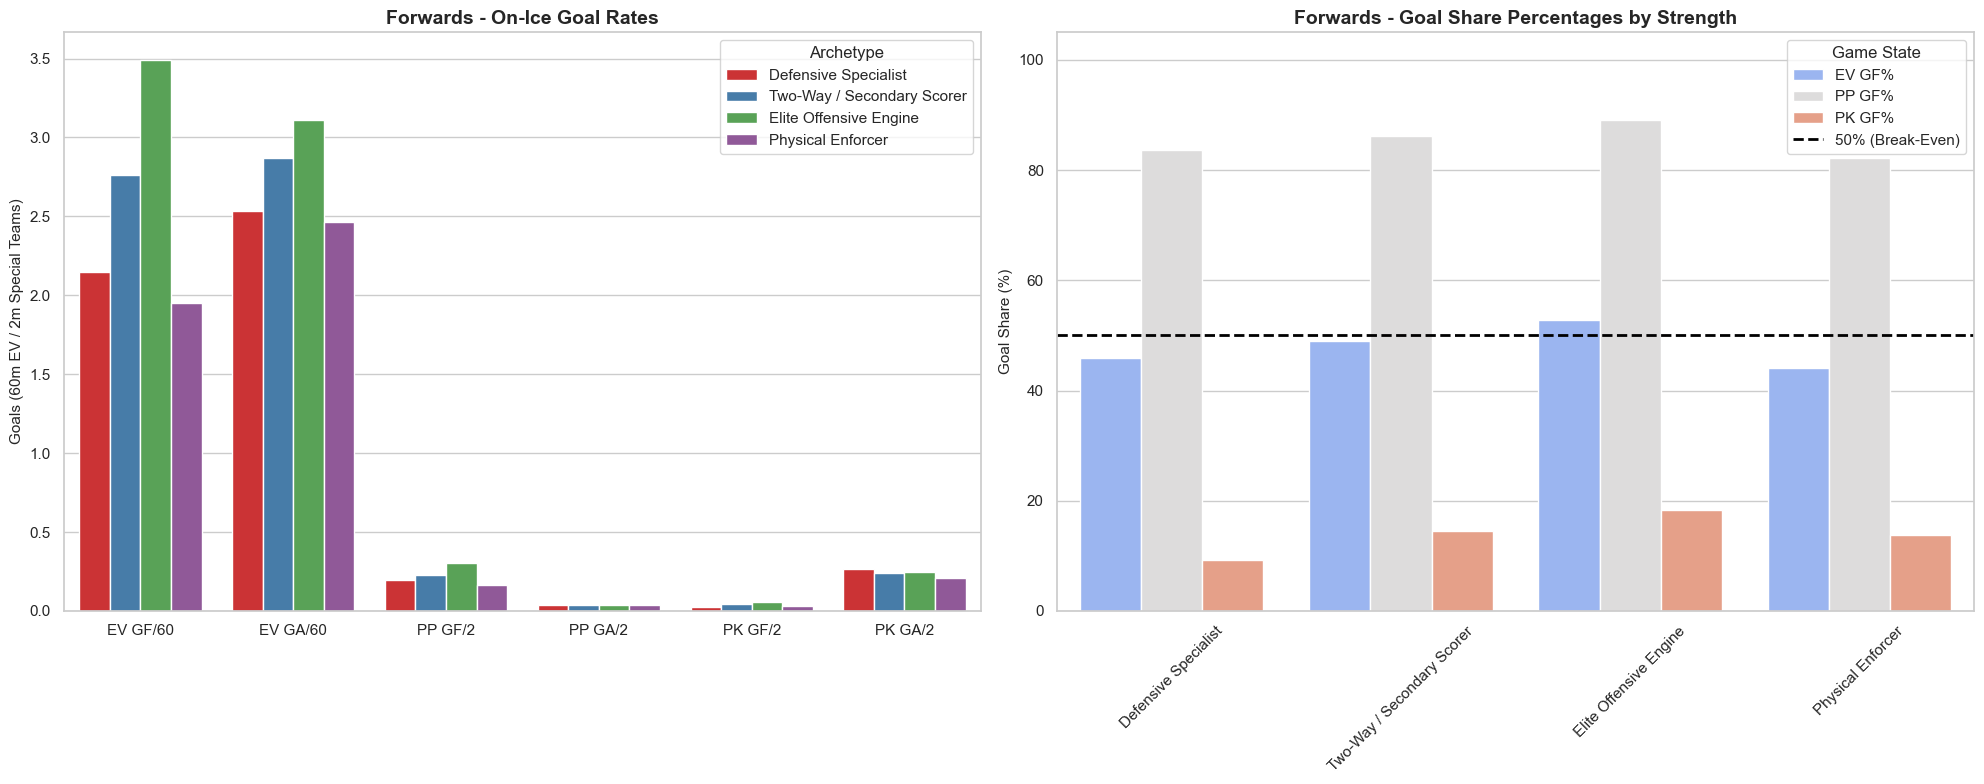

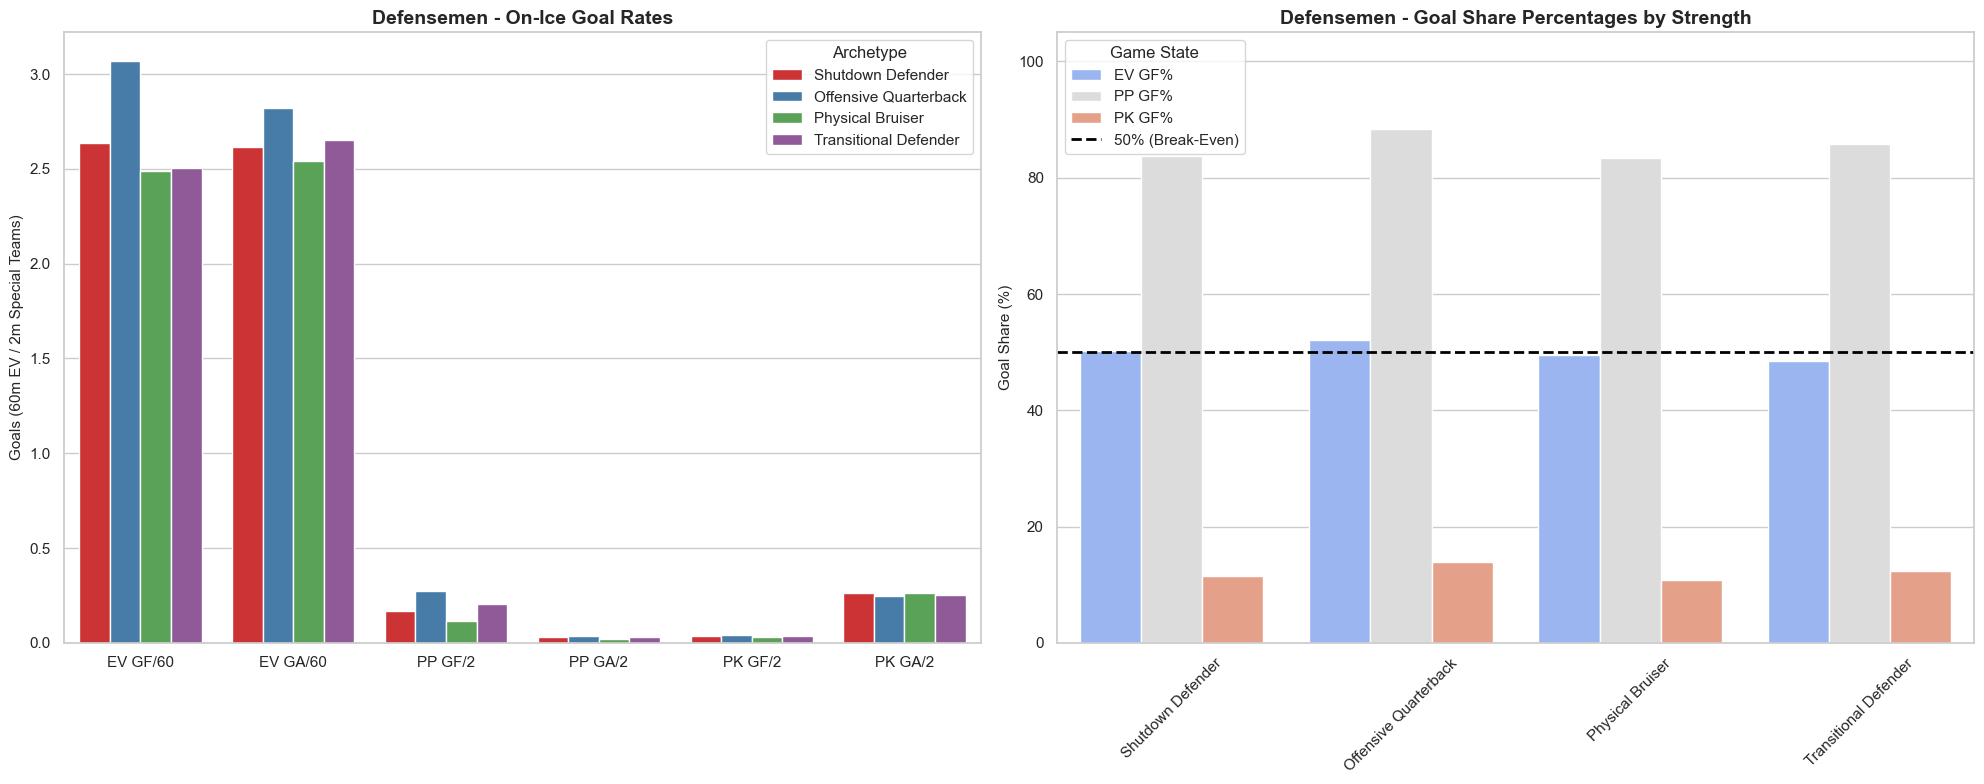

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_goal_shares_and_rates(df, role_name):
    """
    Calculates the aggregate goal rates (Per 60 / Per 2) and goal shares (GF%) 
    for each player archetype. Generates a side-by-side dashboard comparing 
    scoring pace and overall on-ice effectiveness.
    """
    results = []
    
    # Loop through each custom archetype we defined
    for archetype in df['Archetype'].unique():
        c_data = df[df['Archetype'] == archetype]
        
        # 1. Aggregate total minutes played by all players in this archetype
        ev_mins = (c_data['evenStrengthTimeOnIcePerGame'] * c_data['gamesPlayed']).sum() / 60
        pp_mins = (c_data['powerPlayTimeOnIcePerGame'] * c_data['gamesPlayed']).sum() / 60
        sh_mins = (c_data['shortHandedTimeOnIcePerGame'] * c_data['gamesPlayed']).sum() / 60
        
        # 2. Aggregate Raw Goals (Correcting the NHL API Special Teams quirk)
        # Note: The API tracks 'Goals Against' from the perspective of the goalie, 
        # so a PP Goal Against is actually a Short-Handed Goal allowed by the PP unit.
        ev_gf = c_data['evenStrengthGoalsFor'].sum()
        ev_ga = c_data['evenStrengthGoalsAgainst'].sum()
        
        pp_gf = c_data['powerPlayGoalFor'].sum()
        pp_ga_actual = c_data['shortHandedGoalsAgainst'].sum() 
        
        pk_gf = c_data['shortHandedGoalsFor'].sum()
        pk_ga_actual = c_data['powerPlayGoalsAgainst'].sum() 
        
        # 3. Calculate Standardized Rates 
        # We use max(mins, 1) to prevent ZeroDivisionError for types that don't play special teams
        ev_gf60 = (ev_gf / max(ev_mins, 1)) * 60
        ev_ga60 = (ev_ga / max(ev_mins, 1)) * 60
        pp_gf2 = (pp_gf / max(pp_mins, 1)) * 2
        pp_ga2 = (pp_ga_actual / max(pp_mins, 1)) * 2
        sh_gf2 = (pk_gf / max(sh_mins, 1)) * 2
        sh_ga2 = (pk_ga_actual / max(sh_mins, 1)) * 2
        
        # 4. Calculate Goal Shares (GF / Total Goals)
        total_ev = ev_gf + ev_ga
        ev_gf_pct = (ev_gf / total_ev) * 100 if total_ev > 0 else 0
        
        total_pp = pp_gf + pp_ga_actual
        pp_gf_pct = (pp_gf / total_pp) * 100 if total_pp > 0 else 0
        
        total_pk = pk_gf + pk_ga_actual
        pk_gf_pct = (pk_gf / total_pk) * 100 if total_pk > 0 else 0
        
        results.append({
            'Archetype': archetype,
            'EV GF/60': ev_gf60, 'EV GA/60': ev_ga60,
            'PP GF/2': pp_gf2, 'PP GA/2': pp_ga2,
            'PK GF/2': sh_gf2, 'PK GA/2': sh_ga2,
            'EV GF%': ev_gf_pct,
            'PP GF%': pp_gf_pct,
            'PK GF%': pk_gf_pct
        })
        
    results_df = pd.DataFrame(results)
    
    # PLOTTING THE DASHBOARD
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1.5, 1.5]})
    sns.set_theme(style="whitegrid")
    
    # Chart 1 (Left): Standardized Goal Rates
    rates_cols = ['Archetype', 'EV GF/60', 'EV GA/60', 'PP GF/2', 'PP GA/2', 'PK GF/2', 'PK GA/2']
    melted_rates = results_df[rates_cols].melt(id_vars='Archetype', var_name='Metric', value_name='Rate')
    sns.barplot(data=melted_rates, x='Metric', y='Rate', hue='Archetype', palette='Set1', ax=axes[0])
    axes[0].set_title(f'{role_name} - On-Ice Goal Rates', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Goals (60m EV / 2m Special Teams)', fontsize=11)
    axes[0].set_xlabel('')
    axes[0].legend(title='Archetype', loc='upper right')
    
    # Chart 2 (Right): Goal Shares by Strength
    shares_cols = ['Archetype', 'EV GF%', 'PP GF%', 'PK GF%']
    melted_shares = results_df[shares_cols].melt(id_vars='Archetype', var_name='Strength', value_name='Share%')
    
    sns.barplot(data=melted_shares, x='Archetype', y='Share%', hue='Strength', palette='coolwarm', ax=axes[1])
    axes[1].axhline(y=50, color='black', linestyle='--', linewidth=2, label='50% (Break-Even)')
    axes[1].set_title(f'{role_name} - Goal Share Percentages by Strength', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Goal Share (%)', fontsize=11)
    axes[1].set_xlabel('')
    axes[1].set_ylim(0, 105) 
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Game State')
    
    plt.tight_layout()
    plt.show()

# Execute Visualization
print("Generating Advanced Performance Dashboard...")
analyze_goal_shares_and_rates(fwds_clustered, "Forwards")
analyze_goal_shares_and_rates(defs_clustered, "Defensemen")

### Step 9: Puck Possession (Corsi/SAT) Verification
Because goal scoring in hockey is heavily influenced by variance and "puck luck" (e.g., shooting percentages and goaltending), we must verify our findings using underlying play-driving metrics. 

Here we analyze Shot Attempt Percentage (SAT%, also known as Corsi). SAT% measures the total share of shot attempts a team generates while a specific player is on the ice. If an archetype maintains an SAT% above the 50% break-even line, it proves that their specific playstyle organically drives possession and controls the flow of the game.

Running Possession Control Analysis...


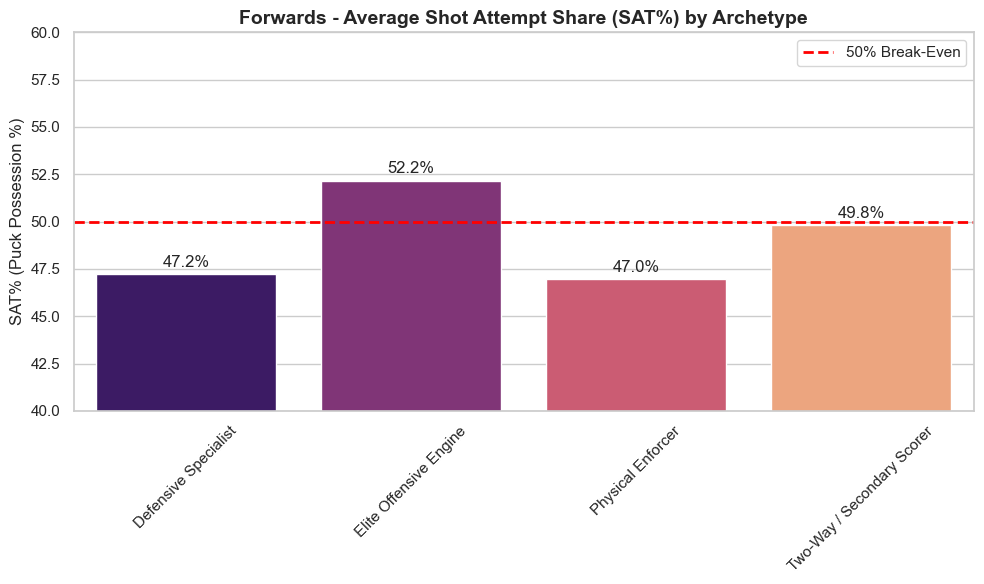

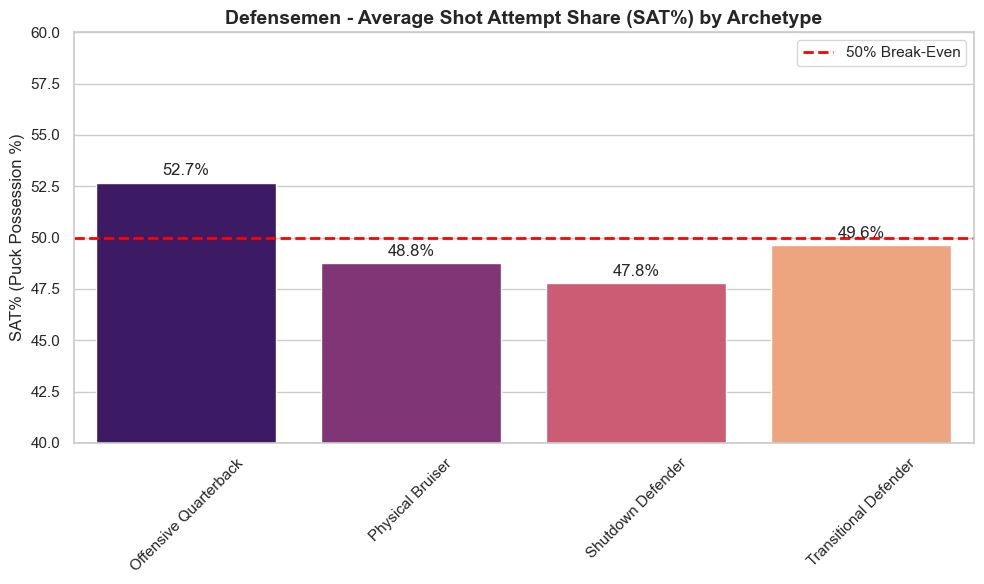

In [31]:
def analyze_possession(df, role_name):
    """
    Visualizes the average Shot Attempt Share (SAT%) for each archetype to 
    determine which playstyles consistently dictate puck possession.
    """
    # The NHL API returns SAT% as a decimal (e.g., 0.505). Convert to standard 0-100 percentage.
    df['satPercentage_100'] = df['satPercentage'] * 100
    
    # Calculate the mean possession for each group
    cluster_means = df.groupby('Archetype')[['satPercentage_100']].mean().round(2).reset_index()
    
    # Setup visualization
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Render the bar plot
    ax = sns.barplot(data=cluster_means, x='Archetype', y='satPercentage_100', palette='magma')
    
    # Add a horizontal line representing the break-even possession metric
    plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% Break-Even')
    
    # Formatting
    plt.title(f'{role_name} - Average Shot Attempt Share (SAT%) by Archetype', fontsize=14, fontweight='bold')
    plt.ylabel('SAT% (Puck Possession %)', fontsize=12)
    plt.xlabel('')
    plt.ylim(40, 60) # Y-axis restricted to 40-60 to highlight the margins of possession
    plt.xticks(rotation=45)
    plt.legend()
    
    # Add exact data labels above each bar for clarity
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3)
        
    plt.tight_layout()
    plt.show()

# Execute Visualization
print("Running Possession Control Analysis...")
analyze_possession(fwds_clustered, "Forwards")
analyze_possession(defs_clustered, "Defensemen")

### Step 10: Real-World Application (Player DNA Profiling)
To validate our unsupervised learning model, we transition from macro-level cluster analysis to micro-level individual scouting. We generate a normalized "Player DNA" radar chart that overlays a specific, real-world player's statistical shape over the average shape of their assigned K-Means archetype. 

By scaling stats from 0 to 1 (using `MinMaxScaler`), we can visually demonstrate exactly *why* the algorithm assigned a player to a specific group, and whether that player is over-performing or under-performing the baseline expectations of that role.

Generating DNA Profile for: McDavid


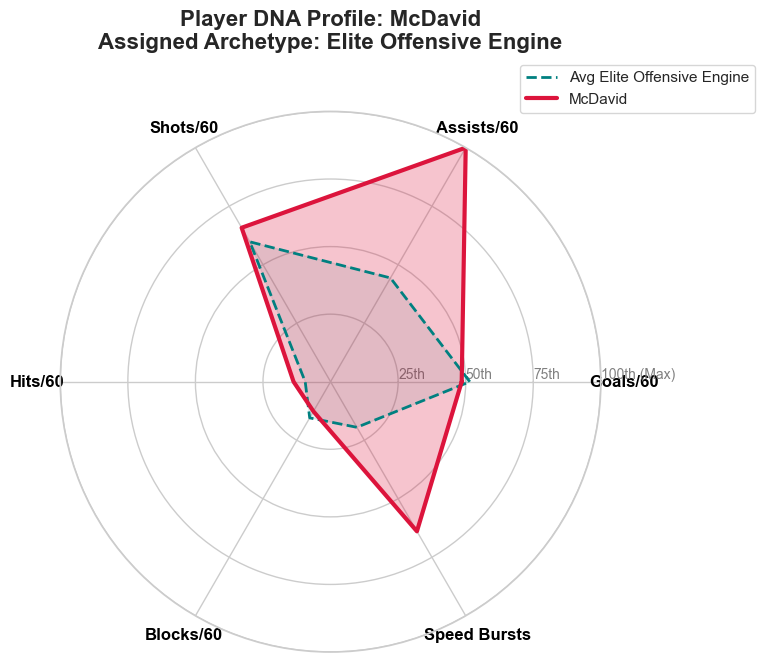

Generating DNA Profile for: Reaves


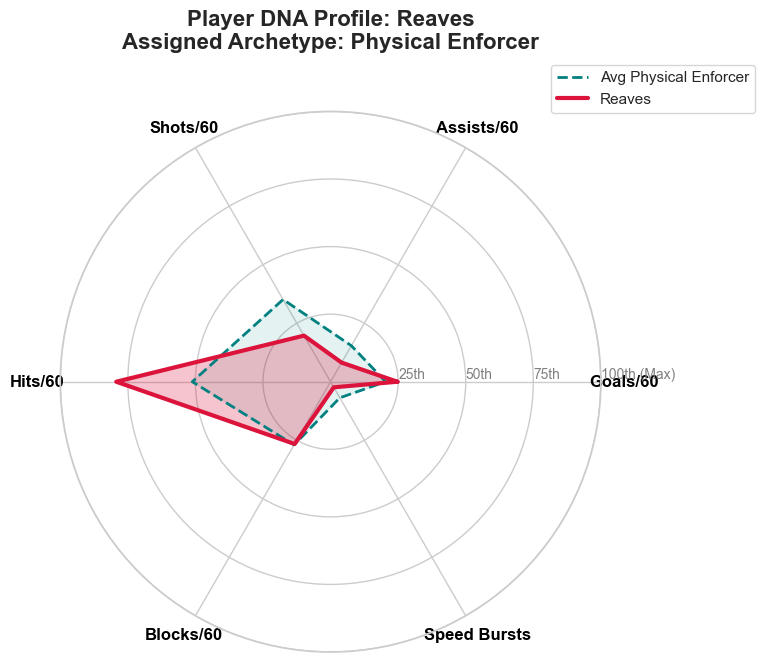

Generating DNA Profile for: Makar


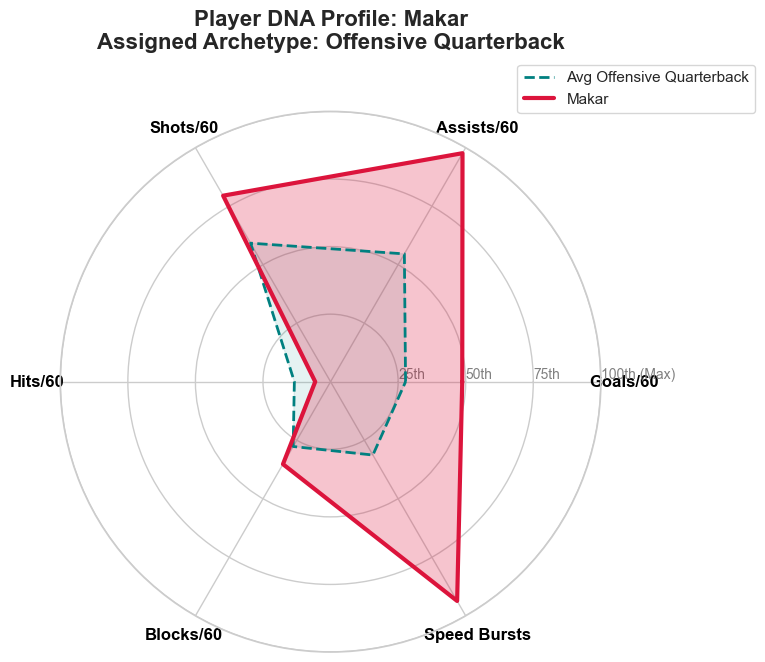

In [32]:
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler

def generate_player_radar(df, player_name):
    """
    Generates a polar radar chart comparing a specific player's normalized 
    statistics to the mathematical average of their assigned K-Means archetype.
    """
    print(f"Generating DNA Profile for: {player_name}")
    
    # 1. Define the specific dimensions to plot (Balanced across offense, defense, speed)
    radar_features = [
        'goalsPer60', 'assistsPer60', 'shotsPer60', 
        'hitsPer60', 'blockedShotsPer60', 'skatingSpeed.burstsOver20.value'
    ]
    labels = ['Goals/60', 'Assists/60', 'Shots/60', 'Hits/60', 'Blocks/60', 'Speed Bursts']
    
    # 2. Normalize the data (0 to 1 range)
    # This allows us to plot a high-volume stat (like speed bursts) on the same 
    # visual axis as a low-volume stat (like goals per 60).
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[radar_features])
    scaled_df = pd.DataFrame(scaled_data, columns=radar_features, index=df.index)
    scaled_df['lastName'] = df['lastName']
    scaled_df['Archetype'] = df['Archetype']
    
    # 3. Locate the target player in the normalized dataset
    player_data = scaled_df[scaled_df['lastName'].str.contains(player_name, case=False, na=False)]
    if player_data.empty:
        print(f"Player '{player_name}' not found in dataset.")
        return
        
    player_stats = player_data.iloc[0][radar_features].values.tolist()
    player_archetype = player_data.iloc[0]['Archetype']
    actual_name = player_data.iloc[0]['lastName']
    
    # 4. Extract the baseline averages for their assigned archetype
    archetype_data = scaled_df[scaled_df['Archetype'] == player_archetype]
    archetype_stats = archetype_data[radar_features].mean().values.tolist()
    
    # 5. Math for the Radar Chart Geometry
    # We append the first value to the end of the list to "close the loop" of the polygon
    player_stats += player_stats[:1]
    archetype_stats += archetype_stats[:1]
    angles = [n / float(len(labels)) * 2 * math.pi for n in range(len(labels))]
    angles += angles[:1]
    
    # 6. Render the Polar Plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Setup axis ticks and circular gridlines
    plt.xticks(angles[:-1], labels, color='black', size=12, fontweight='bold')
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75, 1.0], ["25th", "50th", "75th", "100th (Max)"], color="grey", size=10)
    plt.ylim(0, 1)
    
    # Plot the Archetype Average (Teal Baseline)
    ax.plot(angles, archetype_stats, linewidth=2, linestyle='--', color='teal', label=f'Avg {player_archetype}')
    ax.fill(angles, archetype_stats, color='teal', alpha=0.1)
    
    # Plot the Target Player (Crimson Overlay)
    ax.plot(angles, player_stats, linewidth=3, linestyle='solid', color='crimson', label=actual_name)
    ax.fill(angles, player_stats, color='crimson', alpha=0.25)
    
    plt.title(f"Player DNA Profile: {actual_name}\nAssigned Archetype: {player_archetype}", size=16, fontweight='bold', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# EXECUTE: Run specific player tests
# ---------------------------------------------------------
generate_player_radar(fwds_clustered, "McDavid") 
generate_player_radar(fwds_clustered, "Reaves") 
generate_player_radar(defs_clustered, "Makar")